# Rotation Transformations

## Purpose

Understand rotation matrices as transformations that change direction while preserving length.

This notebook focuses on 2D rotation.

## Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-5, 5), ylim=(-5, 5), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_transformation(ax, original, transformed, original_label="v", transformed_label="A @ v"):
    draw_vector(ax, original, label=original_label, label_offset=(0.1, 0.1))
    draw_vector(ax, transformed, label=transformed_label, label_offset=(0.1, -0.35), width=0.01)

## A 90-degree rotation

A 90-degree counter-clockwise rotation can be represented by this matrix:

$$
R =
\begin{bmatrix}
0 & -1 \\
1 & 0
\end{bmatrix}
$$

When applied to a vector, it rotates that vector by 90 degrees around the origin.

In [2]:
R = np.array([
    [0, -1],
    [1, 0],
])

v = np.array([2, 1])

rotated_v = R @ v

print("v:", v)
print("R @ v:", rotated_v)

v: [2 1]
R @ v: [-1  2]


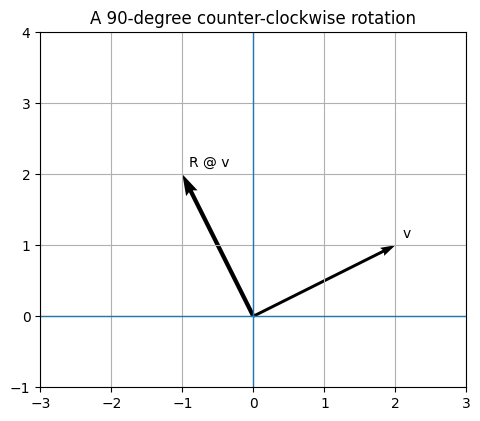

In [3]:
fig, ax = setup_vector_plot(xlim=(-3, 3), ylim=(-1, 4), figsize=(5.5, 5))

draw_vector(ax, v, label="v", label_offset=(0.1, 0.1))
draw_vector(ax, rotated_v, label="R @ v", label_offset=(0.1, 0.1), width=0.01)

ax.set_title("A 90-degree counter-clockwise rotation")
plt.show()

The vector \(v = [2, 1]\) becomes \([-1, 2]\).

The vector has rotated, but its length has not changed.

## The 2D rotation matrix

The general 2D rotation matrix is:

$$
R_\theta =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

where \(	heta\) is the rotation angle.

Positive angles rotate counter-clockwise.

In [4]:
def rotation_matrix_degrees(degrees):
    theta = np.deg2rad(degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

## Rotating by an angle

Let's rotate a vector by 45 degrees.

In [5]:
v = np.array([3, 0])
R_45 = rotation_matrix_degrees(45)

rotated_v = R_45 @ v

print("R_45:")
print(R_45)
print()
print("v:", v)
print("R_45 @ v:", rotated_v)

R_45:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

v: [3 0]
R_45 @ v: [2.12132034 2.12132034]


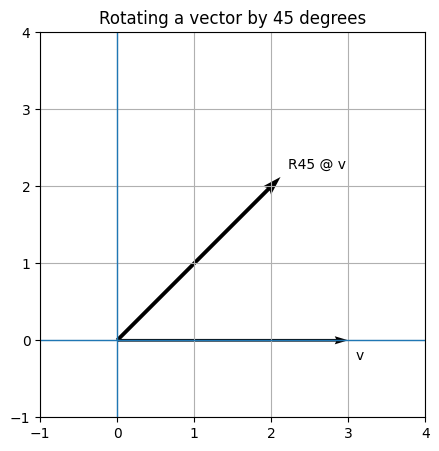

In [6]:
fig, ax = setup_vector_plot(xlim=(-1, 4), ylim=(-1, 4), figsize=(5, 5))

draw_vector(ax, v, label="v", label_offset=(0.1, -0.25))
draw_vector(ax, rotated_v, label="R45 @ v", label_offset=(0.1, 0.1), width=0.01)

ax.set_title("Rotating a vector by 45 degrees")
plt.show()

Because of floating-point arithmetic, the result may contain tiny rounding differences.

That is normal.

## Rotation preserves length

A pure rotation changes direction but preserves vector length.

Let's check that numerically.

In [7]:
v = np.array([3, 0])
rotated_v = R_45 @ v

print("||v||:", np.linalg.norm(v))
print("||R_45 @ v||:", np.linalg.norm(rotated_v))

||v||: 3.0
||R_45 @ v||: 3.0000000000000004


The lengths are the same, apart from tiny floating-point rounding.

## Trying several rotation angles

We can apply different rotation matrices to the same vector.

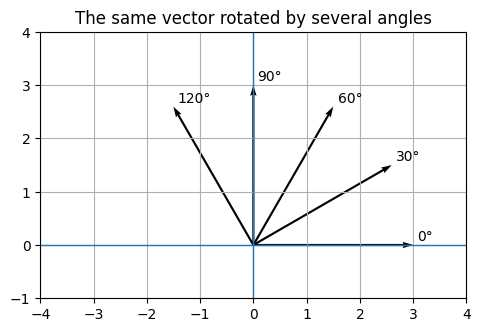

In [8]:
v = np.array([3, 0])
angles = [0, 30, 60, 90, 120]

fig, ax = setup_vector_plot(xlim=(-4, 4), ylim=(-1, 4), figsize=(5.5, 5))

for angle in angles:
    R = rotation_matrix_degrees(angle)
    rotated_v = R @ v
    draw_vector(ax, rotated_v, label=f"{angle}°", label_offset=(0.08, 0.08), width=0.005)

ax.set_title("The same vector rotated by several angles")
plt.show()

Every transformed vector has the same length.

Only the direction changes.

## Rotation changes direction

A rotation matrix is different from a scaling matrix.

Scaling changes length.

Rotation changes direction.

A pure rotation preserves length.

In [9]:
v = np.array([2, 1])
R_60 = rotation_matrix_degrees(60)
rotated_v = R_60 @ v

print("v:", v)
print("R_60 @ v:", rotated_v)
print()
print("length before:", np.linalg.norm(v))
print("length after:", np.linalg.norm(rotated_v))

v: [2 1]
R_60 @ v: [0.1339746  2.23205081]

length before: 2.23606797749979
length after: 2.2360679774997894


## Summary

- A rotation matrix rotates vectors around the origin.
- Positive angles rotate counter-clockwise.
- The 2D rotation matrix uses sine and cosine.
- Pure rotation preserves vector length.
- Rotation is another example of matrix-as-transformation.

## Next step

Next, we will look at basis vectors and matrix columns.